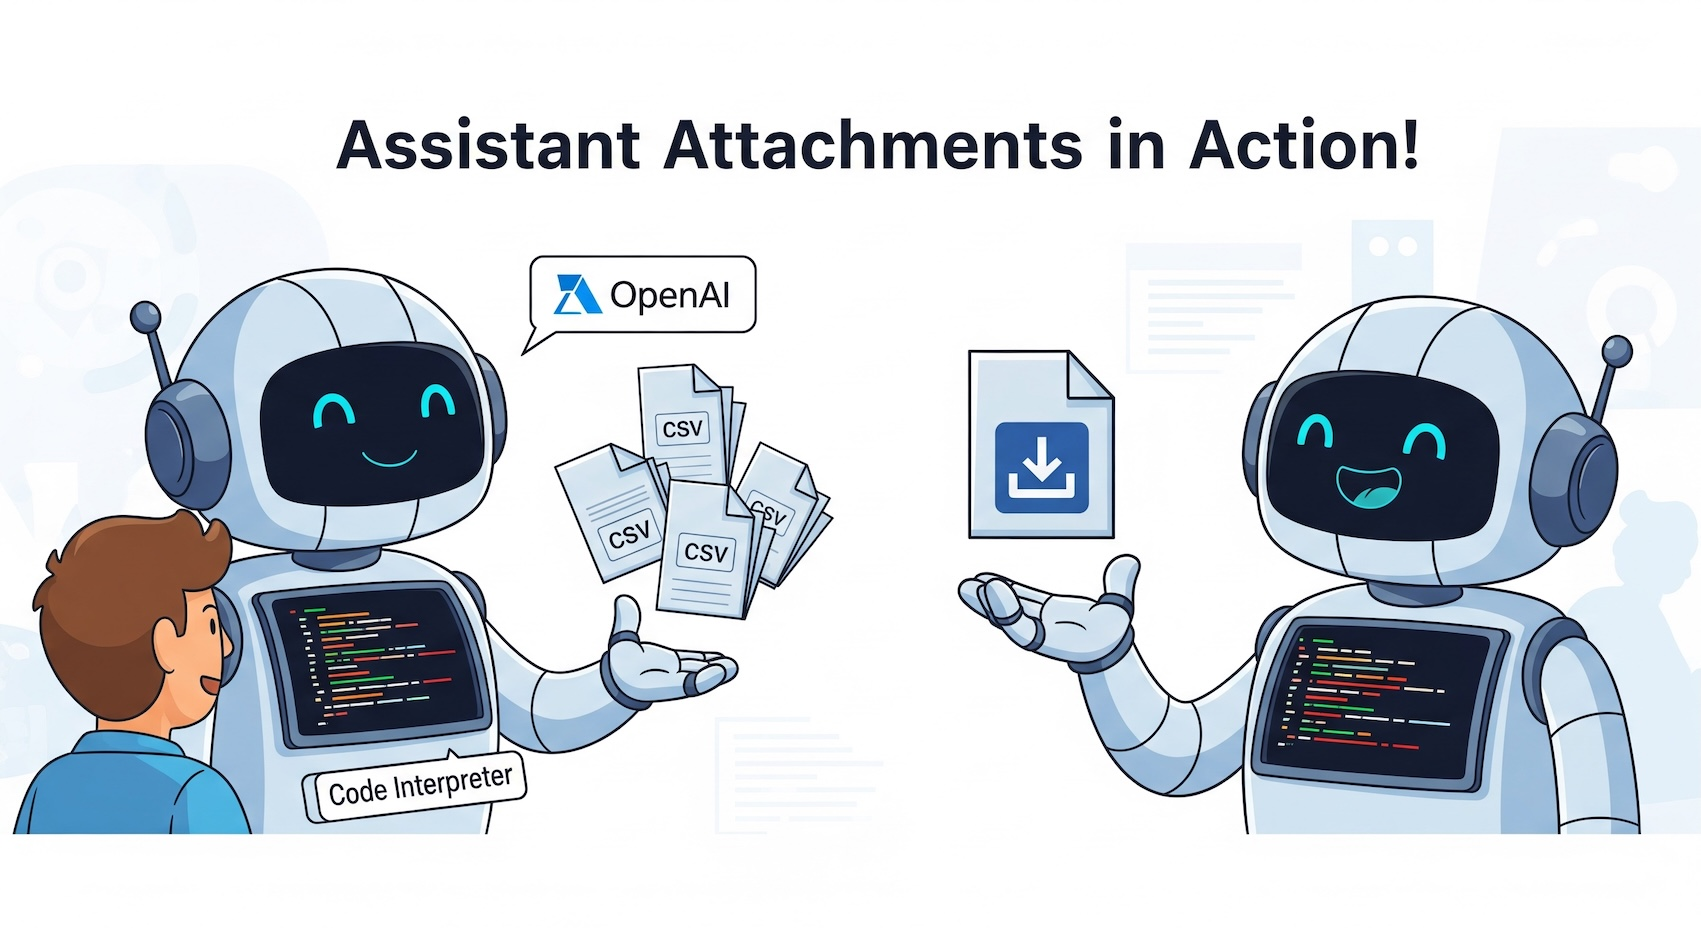

# Assistant attachments

This notebook demonstrates the use of the Azure OpenAI API to interact with an assistant.

The key steps covered are:

1.  **Azure OpenAI Client Setup**: Initialize the Azure OpenAI client using credentials stored in Colab's Secrets Manager.
2.  **File Management**: Delete existing files and upload local CSV files to the Azure OpenAI environment for use with the assistant.
3.  **Assistant and Thread Creation**: Create an assistant with a specific role and tools (code interpreter) and an initial thread with a user message and attached files.
4.  **Running the Assistant**: Execute the assistant on the created thread and poll for the completion of the run.
5.  **Displaying Results**: Retrieve and display the messages from the thread, including the assistant's response.
6.  **Retrieving and Providing Download Link for Generated File**: Extract information about a file generated by the assistant, encode its content, and provide a data URL link for downloading the file as a markdown link.

This notebook provides a basic workflow for using Azure OpenAI assistants with file handling and code interpretation capabilities.

In [ ]:
from openai import AzureOpenAI
from google.colab import userdata
client = AzureOpenAI(api_key=userdata.get('AZURE_API_KEY'),
                     azure_endpoint=userdata.get('AZURE_BASE_URL'),
                     api_version=userdata.get('AZURE_API_VERSION'), )
# AzureOpenAI
# client.models.list()

In [ ]:
for f in client.files.list().data:
    client.files.delete(f.id)

In [ ]:
files_paths =[
    "/content/sample_data/california_housing_train.csv",
    "/content/sample_data/california_housing_test.csv"
]
def upload_to_openai_assistant(file_path: str):
    with open(file_path, "rb") as file:
        file_openai = client.files.create( file=file, purpose="assistants" ).id
        return { "file_id": file_openai, "tools": [{"type": "code_interpreter"}] }
attachments = list(map(upload_to_openai_assistant, files_paths))
attachments

[{'file_id': 'assistant-1FPpRlsA3LxY90b1oSkkEwjh',
  'tools': [{'type': 'code_interpreter'}]},
 {'file_id': 'assistant-cr5Z29xYGoQvjzWjf6QVTK6Q',
  'tools': [{'type': 'code_interpreter'}]}]

In [ ]:
client.files.list().data[0]

FileObject(id='assistant-cr5Z29xYGoQvjzWjf6QVTK6Q', bytes=301141, created_at=1735251512, filename='california_housing_test.csv', object='file', purpose='assistants', status='processed', status_details=None)

In [ ]:
empty_thread = client.beta.threads.create()

In [ ]:
assistant = client.beta.assistants.create(
    name="Data visualizer",
    description="You are great at creating Data analyzer.",
    model="gpt-4o",
    tools=[{"type": "code_interpreter"}],
)

In [ ]:
thread = client.beta.threads.create(
    messages=[
        {
            "role": "user",
            "content": "Describe these csv files.",
            **({"attachments": attachments} if attachments else {})
        }
    ]
)

In [ ]:
run = client.beta.threads.runs.create_and_poll(
    thread_id=thread.id,
    assistant_id=assistant.id
)

In [ ]:
from pprint import pprint
if run.status == 'completed':
    messages = client.beta.threads.messages.list(thread_id=thread.id, order="asc" )
    pprint(messages.model_dump()['data'],width=250)
else:
    print(run.status)

[{'assistant_id': None,
  'attachments': [{'file_id': 'assistant-cr5Z29xYGoQvjzWjf6QVTK6Q', 'tools': [{'type': 'code_interpreter'}]}, {'file_id': 'assistant-1FPpRlsA3LxY90b1oSkkEwjh', 'tools': [{'type': 'code_interpreter'}]}],
  'completed_at': None,
  'content': [{'text': {'annotations': [], 'value': 'Describe these csv files.'}, 'type': 'text'}],
  'created_at': 1735251548,
  'id': 'msg_xYlB0zdxpBrPwT9E4rcS1IUf',
  'incomplete_at': None,
  'incomplete_details': None,
  'metadata': {},
  'object': 'thread.message',
  'role': 'user',
  'run_id': None,
  'status': None,
  'thread_id': 'thread_a2wY0VvYhJaufaHo07tAUAs0'},
 {'assistant_id': 'asst_LheNDbAtGCIOChtUOxkcKD95',
  'attachments': [],
  'completed_at': None,
  'content': [{'text': {'annotations': [],
                        'value': 'The two CSV files you provided contain data with the following structure:\n'
                                 '\n'
                                 '### First CSV File:\n'
                            

In [ ]:
thread = client.beta.threads.create(
    messages=[
        {
            "role": "user",
            "content": "save python libs in the environment into a txt file, and then provide me a markdown link to download it in a separated message",
        }
    ]
)

In [ ]:
run = client.beta.threads.runs.create_and_poll(
    thread_id=thread.id,
    assistant_id=assistant.id
)

In [ ]:
from pprint import pprint
if run.status == 'completed':
    messages = client.beta.threads.messages.list(thread_id=thread.id, order="asc")
    pprint(messages.model_dump()['data'],width=250)
else:
    print(run.status)

[{'assistant_id': None,
  'attachments': [],
  'completed_at': None,
  'content': [{'text': {'annotations': [], 'value': 'save python libs in the environment into a txt file, and then provide me a markdown linkv to download it in a separated message'}, 'type': 'text'}],
  'created_at': 1735253045,
  'id': 'msg_ke5rObIdJNMjnz0nke5BBTSi',
  'incomplete_at': None,
  'incomplete_details': None,
  'metadata': {},
  'object': 'thread.message',
  'role': 'user',
  'run_id': None,
  'status': None,
  'thread_id': 'thread_5VfP2CHGiFlr5xntvTOECoNO'},
 {'assistant_id': 'asst_LheNDbAtGCIOChtUOxkcKD95',
  'attachments': [{'file_id': 'assistant-T9pM9bMs824osk5IWy4fsfas', 'tools': [{'type': 'code_interpreter'}]}],
  'completed_at': None,
  'content': [{'text': {'annotations': [{'end_index': 158, 'file_path': {'file_id': 'assistant-T9pM9bMs824osk5IWy4fsfas'}, 'start_index': 124, 'text': 'sandbox:/mnt/data/requirements.txt', 'type': 'file_path'}],
                        'value': 'You can download the 

In [ ]:
text = messages.model_dump()['data'][-1]['content'][0]['text']['value']
annotations = messages.model_dump()['data'][-1]['content'][0]['text']['annotations']

In [ ]:
import base64
content_byte = client.files.content(file_id=annotations[0]['file_path']['file_id']).read()
encoded_content = base64.b64encode(content_byte).decode('utf-8')
data_url = f"data:text/plain;base64,{encoded_content}"

In [ ]:
modified_text = text[:annotations[0]['start_index']] + data_url + text[annotations[0]['end_index']:]

# display(HTML(modified_text))
display(modified_text)
display(Markdown(modified_text))

'You can download the file with the list of installed Python libraries from the following link:\n\n[Download requirements.txt](data:text/plain;base64,YWJzbC1weT09Mi4xLjAKYWZmaW5lPT0yLjQuMAphaW9odHRwPT0zLjguMQphaW9zaWduYWw9PTEuMy4xCmFuYWx5dGljcy1weXRob249PTEuNC5wb3N0MQphbnlpbz09My43LjEKYW55dHJlZT09Mi44LjAKYXJnY29tcGxldGU9PTEuMTAuMwphcmdvbjItY2ZmaT09MjMuMS4wCmFyZ29uMi1jZmZpLWJpbmRpbmdzPT0yMS4yLjAKYXJ2aXo9PTAuMTUuMQphc24xY3J5cHRvPT0xLjUuMQphc3R0b2tlbnM9PTIuNC4xCmFzeW5jLXRpbWVvdXQ9PTQuMC4zCmF0dHJzPT0yMy4yLjAKYXVkaW9yZWFkPT0zLjAuMQpCYWJlbD09Mi4xNS4wCmJhY2tjYWxsPT0wLjIuMApiYWNrb2ZmPT0xLjEwLjAKYmFja3BvcnRzLnpvbmVpbmZvPT0wLjIuMQpiYXNlbWFwPT0xLjMuMgpiYXNlbWFwLWRhdGE9PTEuMy4yCmJjcnlwdD09NC4xLjMKYmVhdXRpZnVsc291cDQ9PTQuOC4yCmJsZWFjaD09Ni4xLjAKYmxpbmtlcj09MS44LjIKYmxpcz09MC43LjExCmJva2VoPT0yLjQuMApicmFuY2E9PTAuNy4yCkJyb3RsaT09MS4xLjAKY2FjaGV0b29scz09NS4zLjMKY2Fpcm9jZmZpPT0xLjcuMQpDYWlyb1NWRz09Mi41LjIKY2FtZWxvdC1weT09MC4xMC4xCmNhdGFsb2d1ZT09Mi4wLjEwCmNlcnRpZmk9PTIwMTkuMTEuMjgKY2ZmaT09MS4xNi4wCmNoYX

You can download the file with the list of installed Python libraries from the following link:

[Download requirements.txt](data:text/plain;base64,YWJzbC1weT09Mi4xLjAKYWZmaW5lPT0yLjQuMAphaW9odHRwPT0zLjguMQphaW9zaWduYWw9PTEuMy4xCmFuYWx5dGljcy1weXRob249PTEuNC5wb3N0MQphbnlpbz09My43LjEKYW55dHJlZT09Mi44LjAKYXJnY29tcGxldGU9PTEuMTAuMwphcmdvbjItY2ZmaT09MjMuMS4wCmFyZ29uMi1jZmZpLWJpbmRpbmdzPT0yMS4yLjAKYXJ2aXo9PTAuMTUuMQphc24xY3J5cHRvPT0xLjUuMQphc3R0b2tlbnM9PTIuNC4xCmFzeW5jLXRpbWVvdXQ9PTQuMC4zCmF0dHJzPT0yMy4yLjAKYXVkaW9yZWFkPT0zLjAuMQpCYWJlbD09Mi4xNS4wCmJhY2tjYWxsPT0wLjIuMApiYWNrb2ZmPT0xLjEwLjAKYmFja3BvcnRzLnpvbmVpbmZvPT0wLjIuMQpiYXNlbWFwPT0xLjMuMgpiYXNlbWFwLWRhdGE9PTEuMy4yCmJjcnlwdD09NC4xLjMKYmVhdXRpZnVsc291cDQ9PTQuOC4yCmJsZWFjaD09Ni4xLjAKYmxpbmtlcj09MS44LjIKYmxpcz09MC43LjExCmJva2VoPT0yLjQuMApicmFuY2E9PTAuNy4yCkJyb3RsaT09MS4xLjAKY2FjaGV0b29scz09NS4zLjMKY2Fpcm9jZmZpPT0xLjcuMQpDYWlyb1NWRz09Mi41LjIKY2FtZWxvdC1weT09MC4xMC4xCmNhdGFsb2d1ZT09Mi4wLjEwCmNlcnRpZmk9PTIwMTkuMTEuMjgKY2ZmaT09MS4xNi4wCmNoYXJkZXQ9PTQuMC4wCmNoYXJzZXQtbm9ybWFsaXplcj09Mi4xLjEKY2xpY2s9PTguMS43CmNsaWNrLXBsdWdpbnM9PTEuMS4xCmNsaWdqPT0wLjcuMgpjbG91ZHBpY2tsZT09My4wLjAKY211ZGljdD09MS4wLjI0CmNvbW09PTAuMi4yCmNvbXByZXNzZWQtcnRmPT0xLjAuNgpjb3VudHJ5aW5mbz09MC4xLjIKY3J5cHRvZ3JhcGh5PT0zLjQuOApjc3NzZWxlY3QyPT0wLjcuMApjeWNsZXI9PTAuMTIuMQpjeW1lbT09Mi4wLjgKQ3l0aG9uPT0wLjI5LjM2CmRhdGFicmlja3Mtc3FsLWNvbm5lY3Rvcj09MC45LjEKZGJ1cy1weXRob249PTEuMi4xNgpkZWJ1Z3B5PT0xLjguMgpkZWNvcmF0b3I9PTQuNC4yCmRlZnVzZWR4bWw9PTAuNy4xCmRlcHJlY2F0PT0yLjEuMQpkaWxsPT0wLjMuOApkaXN0cm8taW5mbz09MC4yMyt1YnVudHUxLjEKZGxpYj09MTkuMjIuMQpkbnNweXRob249PTIuNi4xCmRvY3gydHh0PT0wLjgKZWJjZGljPT0xLjEuMQpFYm9va0xpYj09MC4xOAplaW5vcHM9PTAuMy4yCmVtYWlsLXZhbGlkYXRvcj09Mi4yLjAKZW50cnlwb2ludHM9PTAuNApldC14bWxmaWxlPT0xLjEuMApleGNlcHRpb25ncm91cD09MS4yLjEKZXhjaGFuZ2UtY2FsZW5kYXJzPT0zLjQKZXhlY3V0aW5nPT0yLjAuMQpleHRyYWN0LW1zZz09MC4yOC43CkZha2VyPT04LjEzLjIKZmFzdGFwaT09MC45NS4yCmZhc3Rqc29uc2NoZW1hPT0yLjIwLjAKZmFzdHByb2dyZXNzPT0xLjAuMwpmZm1wZWctcHl0aG9uPT0wLjIuMApmZm1weT09MC4zLjIKZmlsZWxvY2s9PTMuMTUuNApGaW9uYT09MS44LjIwCmZsYXNrPT0zLjAuMwpGbGFzay1DYWNoZUJ1c3Rlcj09MS4wLjAKRmxhc2stQ29ycz09NC4wLjEKRmxhc2stTG9naW49PTAuNi4zCmZvbGl1bT09MC4xMi4xCmZvbnR0b29scz09NC41My4wCmZwZGY9PTEuNy4yCmZyb3plbmxpc3Q9PTEuNC4xCmZ1dHVyZT09MS4wLjAKZnV6enl3dXp6eT09MC4xOC4wCmdlbnNpbT09NC4xLjAKZ2VvZ3JhcGhpY2xpYj09MS41MgpnZW9wYW5kYXM9PTAuMTAuMgpnZW9weT09Mi4yLjAKZ3JhZGlvPT0yLjIuMTUKZ3JhcGh2aXo9PTAuMTcKZ1RUUz09Mi4yLjMKaDExPT0wLjE0LjAKaDI9PTQuMS4wCmg1bmV0Y2RmPT0xLjEuMApoNXB5PT0zLjYuMApocGFjaz09NC4wLjAKaHRtbDVsaWI9PTEuMQpodHRwY29yZT09MS4wLjUKaHR0cHRvb2xzPT0wLjYuMQpodHRweD09MC4yNy4wCmh5cGVyY29ybj09MC4xNC4zCmh5cGVyZnJhbWU9PTYuMC4xCmlkbmE9PTIuOAppbWFnZWlvPT0yLjM0LjIKaW1hZ2Vpby1mZm1wZWc9PTAuNS4xCklNQVBDbGllbnQ9PTIuMS4wCmltZ2tpdD09MS4yLjIKaW1wb3J0bGliLW1ldGFkYXRhPT04LjAuMAppbXBvcnRsaWItcmVzb3VyY2VzPT02LjQuMAppbmljb25maWc9PTIuMC4wCmlweWtlcm5lbD09Ni4yOS41CmlweXRob249PTguMTIuMwppcHl0aG9uLWdlbnV0aWxzPT0wLjIuMAppc29kYXRlPT0wLjYuMQppdHNkYW5nZXJvdXM9PTIuMi4wCmpheD09MC4yLjI4CmplZGk9PTAuMTkuMQpqaW5qYTI9PTMuMS40CmpvYmxpYj09MS40LjIKanNvbjU9PTAuOS4yNQpqc29ucGlja2xlPT0zLjIuMgpqc29uc2NoZW1hPT00LjIyLjAKanNvbnNjaGVtYS1zcGVjaWZpY2F0aW9ucz09MjAyMy4xMi4xCmp1cHl0ZXItY2xpZW50PT03LjQuOQpqdXB5dGVyLWNvcmU9PTUuMS4zCmp1cHl0ZXItc2VydmVyPT0xLjIzLjUKanVweXRlcmxhYj09My40LjgKanVweXRlcmxhYi1weWdtZW50cz09MC4yLjIKanVweXRlcmxhYi1zZXJ2ZXI9PTIuMTkuMAprZXJhcz09Mi42LjAKa2VyeWtlaW9uPT0yLjEuMTYKa2l3aXNvbHZlcj09MS40LjUKa29yZWFuLWx1bmFyLWNhbGVuZGFyPT0wLjMuMQpsaWJyb3NhPT0wLjguMQpsbHZtbGl0ZT09MC40MS4xCmxvZ3VydT09MC41LjMKbHhtbD09NS4yLjIKbWFya2Rvd24yPT0yLjQuMTMKbWFya2Rvd25pZnk9PTAuOS4zCk1hcmt1cFNhZmU9PTIuMS41Cm1hdHBsb3RsaWI9PTMuNC4zCm1hdHBsb3RsaWItaW5saW5lPT0wLjEuNwptYXRwbG90bGliLXZlbm49PTAuMTEuNgptaXN0dW5lPT0zLjAuMgptaXphbmk9PTAuOS4zCm1uZT09MC4yMy40Cm1vbm90b25pYz09MS42Cm1vdmllcHk9PTEuMC4zCm1wbWF0aD09MS4zLjAKbXRjbm49PTAuMS4xCm11bHRpZGljdD09Ni4wLjUKbXVuY2g9PTQuMC4wCm11cm11cmhhc2g9PTEuMC4xMAptdXRhZ2VuPT0xLjQ1LjEKbmFzaHB5PT0wLjAuMzUKbmJjbGFzc2ljPT0wLjQuNQpuYmNsaWVudD09MC4xMC4wCm5iY29udmVydD09Ny4xNi40Cm5iZm9ybWF0PT01LjEwLjQKbmVzdC1hc3luY2lvPT0xLjYuMApuZXR3b3JreD09Mi42LjMKbmx0az09My42LjMKbm90ZWJvb2s9PTYuNS4xCm5vdGVib29rLXNoaW09PTAuMi40Cm51bWJhPT0wLjU4LjEKbnVtZXhwcj09Mi44LjYKbnVtcHk9PTEuMjEuMgpudW1weS1maW5hbmNpYWw9PTEuMC4wCm9kZnB5PT0xLjQuMQpvbGVmaWxlPT0wLjQ3Cm9wZW5jdi1weXRob249PTQuNS4yLjU0Cm9wZW5weXhsPT0zLjAuMTAKb3B0LWVpbnN1bT09My4zLjAKb3Jqc29uPT0zLjEwLjYKb3NjcnlwdG89PTEuMy4wCnBhY2thZ2luZz09MjQuMQpwYW5kYXM9PTEuMy4yCnBhbmRvY2ZpbHRlcnM9PTEuNS4xCnBhcmFtaWtvPT0zLjQuMApwYXJzbz09MC44LjQKcGF0aGxpYi1hYmM9PTAuMS4xCnBhdGh5PT0wLjExLjAKcGF0c3k9PTAuNS42CnBkZjJpbWFnZT09MS4xNi4zCnBkZmtpdD09MC42LjEKcGRmbWluZXIuc2l4PT0yMDE5MTExMApwZGZwbHVtYmVyPT0wLjUuMjgKcGRmcnc9PTAuNApwZXhwZWN0PT00LjkuMApwaWNrbGVzaGFyZT09MC43LjUKUGlsbG93PT04LjMuMgpwa2d1dGlsLXJlc29sdmUtbmFtZT09MS4zLjEwCnBsYXRmb3JtZGlycz09NC4yLjIKcGxvdGx5PT01LjMuMApwbG90bmluZT09MC4xMC4xCnBsdWdneT09MS41LjAKcG9vY2g9PTEuOC4yCnByZXNoZWQ9PTMuMC45CnByaW9yaXR5PT0yLjAuMApwcm9nbG9nPT0wLjEuMTAKcHJvbWV0aGV1cy1jbGllbnQ9PTAuMjAuMApwcm9tcHQtdG9vbGtpdD09My4wLjQ3CnByb25vdW5jaW5nPT0wLjIuMApwc3V0aWw9PTYuMC4wCnB0eXByb2Nlc3M9PTAuNy4wCnB1cmUtZXZhbD09MC4yLjIKcHk9PTEuMTEuMApQeUF1ZGlvPT0wLjIuMTEKcHljb3VudHJ5PT0yMC43LjMKcHljcGFyc2VyPT0yLjIyCnB5Y3J5cHRvZG9tZT09My4yMC4wCnB5Y3J5cHRvZG9tZXg9PTMuMjAuMApweWRhbnRpYz09MS4xMC4yCnB5ZG90PT0xLjQuMgpweWR1Yj09MC4yNS4xCnB5ZHlmPT0wLjEwLjAKcHlnbWVudHM9PTIuMTguMApQeUdPYmplY3Q9PTMuMzYuMApweWdyYXBodml6PT0xLjcKUHlKV1Q9PTIuOC4wCnB5bG9nPT0xLjEKcHlsdWFjaD09Mi4yLjAKcHltYzM9PTMuMTEuNQpQeU11UERGPT0xLjE5LjYKUHlOYUNsPT0xLjUuMApweU9wZW5TU0w9PTIxLjAuMApweXBhbmRvYz09MS42LjMKcHlwYXJzaW5nPT0zLjEuMgpQeVBERjI9PTEuMjguNgpweXBoZW49PTAuMTUuMApweXByb2o9PTMuNS4wCnB5cHJvdmVyPT0wLjUuNgpweXNocD09Mi4xLjMKcHlzd2lzc2VwaD09Mi4xMC4zLjIKcHl0ZXNzZXJhY3Q9PTAuMy44CnB5dGVzdD09Ni4yLjUKcHl0aDM9PTAuNwpweXRob24tYXB0PT0yLjAuMSt1YnVudHUwLjIwLjQuMQpweXRob24tZGF0ZXV0aWw9PTIuOS4wLnBvc3QwCnB5dGhvbi1kb2N4PT0wLjguMTEKcHl0aG9uLWRvdGVudj09MS4wLjEKcHl0aG9uLW11bHRpcGFydD09MC4wLjkKcHl0aG9uLXBwdHg9PTAuNi4yMQpweXR0c3gzPT0yLjkwCnB5dHo9PTIwMjQuMQpQeVdhdmVsZXRzPT0xLjQuMQpweXhsc2I9PTEuMC44ClB5WUFNTD09Ni4wLjEKcHl6YmFyPT0wLjEuOApweXptcT09MjYuMC4zCnFyY29kZT09Ny4zCnJhcmZpbGU9PTQuMApyYXN0ZXJpbz09MS4yLjEwCnJkZmxpYj09Ni4wLjAKcmVmZXJlbmNpbmc9PTAuMzUuMQpyZWdleD09MjAyNC41LjE1CnJlcG9ydGxhYj09My42LjEKcmVxdWVzdHM9PTIuMzIuMwpyZXF1ZXN0cy11bml4c29ja2V0PT0wLjIuMApyZXNhbXB5PT0wLjQuMwpycGRzLXB5PT0wLjE4LjEKc2Npa2l0LWltYWdlPT0wLjE4LjMKc2Npa2l0LWxlYXJuPT0xLjAKc2NpcHk9PTEuNy4xCnNlYWJvcm49PTAuMTEuMgpzZW12ZXI9PTMuMC4yClNlbmQyVHJhc2g9PTEuOC4zCnNlbnRlbmNlcGllY2U9PTAuMi4wCnNoYXA9PTAuMzkuMApTaGFwZWx5PT0xLjcuMQpzaXg9PTEuMTQuMApzbGljZXI9PTAuMC43CnNtYXJ0LW9wZW49PTcuMC40CnNuaWZmaW89PTEuMy4xCnNub3dmbGFrZS1jb25uZWN0b3ItcHl0aG9uPT0yLjcuMTIKc251Z2dzPT0xLjQuNwpzb3J0ZWRjb250YWluZXJzPT0yLjQuMApTb3VuZEZpbGU9PTAuMTAuMgpzb3Vwc2lldmU9PTIuNQpzcGFjeT09My4xLjYKc3BhY3ktbGVnYWN5PT0zLjAuMTIKU3BlZWNoUmVjb2duaXRpb249PTMuOC4xCnNyc2x5PT0yLjQuOApzdGFjay1kYXRhPT0wLjYuMwpzdGFybGV0dGU9PTAuMjcuMApzdGF0c21vZGVscz09MC4xMy4xCnN2Z2xpYj09MS4xLjAKc3Znd3JpdGU9PTEuNC4xCnN5bXB5PT0xLjgKdGFibGVzPT0zLjYuMQp0YWJ1bGE9PTEuMC41CnRhYnVsYXRlPT0wLjguOQp0ZW5hY2l0eT09OC40LjIKdGVybWluYWRvPT0wLjE4LjEKdGV4dC11bmlkZWNvZGU9PTEuMwp0ZXh0YmxvYj09MC4xNS4zCnRleHRyYWN0PT0xLjYuNApUaGVhbm8tUHlNQz09MS4xLjIKdGhpbmM9PTguMC4xNwp0aHJlYWRwb29sY3RsPT0zLjUuMAp0aHJpZnQ9PTAuMjAuMAp0aWZmZmlsZT09MjAyMy43LjEwCnRpbnljc3MyPT0xLjMuMAp0b21sPT0wLjEwLjIKdG9tbGk9PTIuMC4xCnRvb2x6PT0wLjEyLjEKdG9yY2g9PTEuMTAuMAp0b3JjaGF1ZGlvPT0wLjEwLjAKdG9yY2h0ZXh0PT0wLjYuMAp0b3JjaHZpc2lvbj09MC4xMS4xCnRvcm5hZG89PTYuNC4xCnRxZG09PTQuNjQuMAp0cmFpdGxldHM9PTUuMTQuMwp0cmltZXNoPT0zLjkuMjkKdHlwZXI9PTAuNC4yCnR5cGluZy1leHRlbnNpb25zPT00LjUuMAp0emxvY2FsPT01LjIKdWpzb249PTUuMTAuMAp1bmF0dGVuZGVkLXVwZ3JhZGVzPT0wLjEKdXJsbGliMz09MS4yNS44CnV2aWNvcm49PTAuMzAuMQp1dmxvb3A9PTAuMTkuMApXYW5kPT0wLjYuMTMKd2FzYWJpPT0wLjEwLjEKd2F0Y2hmaWxlcz09MC4yMi4wCndjd2lkdGg9PTAuMi4xMwp3ZWFzeXByaW50PT01My4zCndlYmVuY29kaW5ncz09MC41LjEKd2Vic29ja2V0LWNsaWVudD09MS44LjAKd2Vic29ja2V0cz09MTAuMwp3ZXJremV1Zz09My4wLjMKd29yZGNsb3VkPT0xLjguMQp3cmFwdD09MS4xNi4wCndzcHJvdG89PTEuMi4wCnhhcnJheT09MjAyMy4xLjAKeGFycmF5LWVpbnN0YXRzPT0wLjUuMQp4Z2Jvb3N0PT0xLjQuMgp4bHJkPT0xLjIuMApYbHN4V3JpdGVyPT0zLjIuMAp4bWwtcHl0aG9uPT0wLjQuMwp5YXJsPT0xLjkuNAp6aXBwPT0zLjE5LjIKem9wZmxpPT0wLjIuMwo=)

In [ ]:
modified_text = text[:annotations[0]['start_index']].split('[')[0] + f'<a href="{data_url}" download="requirements.txt">Download Requirements</a>\n\n' + text[annotations[0]['end_index']:].split(')')[-1]

display(modified_text)
display(Markdown(modified_text))

'You can download the file with the list of installed Python libraries from the following link:\n\n<a href="data:text/plain;base64,YWJzbC1weT09Mi4xLjAKYWZmaW5lPT0yLjQuMAphaW9odHRwPT0zLjguMQphaW9zaWduYWw9PTEuMy4xCmFuYWx5dGljcy1weXRob249PTEuNC5wb3N0MQphbnlpbz09My43LjEKYW55dHJlZT09Mi44LjAKYXJnY29tcGxldGU9PTEuMTAuMwphcmdvbjItY2ZmaT09MjMuMS4wCmFyZ29uMi1jZmZpLWJpbmRpbmdzPT0yMS4yLjAKYXJ2aXo9PTAuMTUuMQphc24xY3J5cHRvPT0xLjUuMQphc3R0b2tlbnM9PTIuNC4xCmFzeW5jLXRpbWVvdXQ9PTQuMC4zCmF0dHJzPT0yMy4yLjAKYXVkaW9yZWFkPT0zLjAuMQpCYWJlbD09Mi4xNS4wCmJhY2tjYWxsPT0wLjIuMApiYWNrb2ZmPT0xLjEwLjAKYmFja3BvcnRzLnpvbmVpbmZvPT0wLjIuMQpiYXNlbWFwPT0xLjMuMgpiYXNlbWFwLWRhdGE9PTEuMy4yCmJjcnlwdD09NC4xLjMKYmVhdXRpZnVsc291cDQ9PTQuOC4yCmJsZWFjaD09Ni4xLjAKYmxpbmtlcj09MS44LjIKYmxpcz09MC43LjExCmJva2VoPT0yLjQuMApicmFuY2E9PTAuNy4yCkJyb3RsaT09MS4xLjAKY2FjaGV0b29scz09NS4zLjMKY2Fpcm9jZmZpPT0xLjcuMQpDYWlyb1NWRz09Mi41LjIKY2FtZWxvdC1weT09MC4xMC4xCmNhdGFsb2d1ZT09Mi4wLjEwCmNlcnRpZmk9PTIwMTkuMTEuMjgKY2ZmaT09MS4xNi4wCmNoYXJkZXQ9PTQuMC4wCmNoY

You can download the file with the list of installed Python libraries from the following link:

<a href="data:text/plain;base64,YWJzbC1weT09Mi4xLjAKYWZmaW5lPT0yLjQuMAphaW9odHRwPT0zLjguMQphaW9zaWduYWw9PTEuMy4xCmFuYWx5dGljcy1weXRob249PTEuNC5wb3N0MQphbnlpbz09My43LjEKYW55dHJlZT09Mi44LjAKYXJnY29tcGxldGU9PTEuMTAuMwphcmdvbjItY2ZmaT09MjMuMS4wCmFyZ29uMi1jZmZpLWJpbmRpbmdzPT0yMS4yLjAKYXJ2aXo9PTAuMTUuMQphc24xY3J5cHRvPT0xLjUuMQphc3R0b2tlbnM9PTIuNC4xCmFzeW5jLXRpbWVvdXQ9PTQuMC4zCmF0dHJzPT0yMy4yLjAKYXVkaW9yZWFkPT0zLjAuMQpCYWJlbD09Mi4xNS4wCmJhY2tjYWxsPT0wLjIuMApiYWNrb2ZmPT0xLjEwLjAKYmFja3BvcnRzLnpvbmVpbmZvPT0wLjIuMQpiYXNlbWFwPT0xLjMuMgpiYXNlbWFwLWRhdGE9PTEuMy4yCmJjcnlwdD09NC4xLjMKYmVhdXRpZnVsc291cDQ9PTQuOC4yCmJsZWFjaD09Ni4xLjAKYmxpbmtlcj09MS44LjIKYmxpcz09MC43LjExCmJva2VoPT0yLjQuMApicmFuY2E9PTAuNy4yCkJyb3RsaT09MS4xLjAKY2FjaGV0b29scz09NS4zLjMKY2Fpcm9jZmZpPT0xLjcuMQpDYWlyb1NWRz09Mi41LjIKY2FtZWxvdC1weT09MC4xMC4xCmNhdGFsb2d1ZT09Mi4wLjEwCmNlcnRpZmk9PTIwMTkuMTEuMjgKY2ZmaT09MS4xNi4wCmNoYXJkZXQ9PTQuMC4wCmNoYXJzZXQtbm9ybWFsaXplcj09Mi4xLjEKY2xpY2s9PTguMS43CmNsaWNrLXBsdWdpbnM9PTEuMS4xCmNsaWdqPT0wLjcuMgpjbG91ZHBpY2tsZT09My4wLjAKY211ZGljdD09MS4wLjI0CmNvbW09PTAuMi4yCmNvbXByZXNzZWQtcnRmPT0xLjAuNgpjb3VudHJ5aW5mbz09MC4xLjIKY3J5cHRvZ3JhcGh5PT0zLjQuOApjc3NzZWxlY3QyPT0wLjcuMApjeWNsZXI9PTAuMTIuMQpjeW1lbT09Mi4wLjgKQ3l0aG9uPT0wLjI5LjM2CmRhdGFicmlja3Mtc3FsLWNvbm5lY3Rvcj09MC45LjEKZGJ1cy1weXRob249PTEuMi4xNgpkZWJ1Z3B5PT0xLjguMgpkZWNvcmF0b3I9PTQuNC4yCmRlZnVzZWR4bWw9PTAuNy4xCmRlcHJlY2F0PT0yLjEuMQpkaWxsPT0wLjMuOApkaXN0cm8taW5mbz09MC4yMyt1YnVudHUxLjEKZGxpYj09MTkuMjIuMQpkbnNweXRob249PTIuNi4xCmRvY3gydHh0PT0wLjgKZWJjZGljPT0xLjEuMQpFYm9va0xpYj09MC4xOAplaW5vcHM9PTAuMy4yCmVtYWlsLXZhbGlkYXRvcj09Mi4yLjAKZW50cnlwb2ludHM9PTAuNApldC14bWxmaWxlPT0xLjEuMApleGNlcHRpb25ncm91cD09MS4yLjEKZXhjaGFuZ2UtY2FsZW5kYXJzPT0zLjQKZXhlY3V0aW5nPT0yLjAuMQpleHRyYWN0LW1zZz09MC4yOC43CkZha2VyPT04LjEzLjIKZmFzdGFwaT09MC45NS4yCmZhc3Rqc29uc2NoZW1hPT0yLjIwLjAKZmFzdHByb2dyZXNzPT0xLjAuMwpmZm1wZWctcHl0aG9uPT0wLjIuMApmZm1weT09MC4zLjIKZmlsZWxvY2s9PTMuMTUuNApGaW9uYT09MS44LjIwCmZsYXNrPT0zLjAuMwpGbGFzay1DYWNoZUJ1c3Rlcj09MS4wLjAKRmxhc2stQ29ycz09NC4wLjEKRmxhc2stTG9naW49PTAuNi4zCmZvbGl1bT09MC4xMi4xCmZvbnR0b29scz09NC41My4wCmZwZGY9PTEuNy4yCmZyb3plbmxpc3Q9PTEuNC4xCmZ1dHVyZT09MS4wLjAKZnV6enl3dXp6eT09MC4xOC4wCmdlbnNpbT09NC4xLjAKZ2VvZ3JhcGhpY2xpYj09MS41MgpnZW9wYW5kYXM9PTAuMTAuMgpnZW9weT09Mi4yLjAKZ3JhZGlvPT0yLjIuMTUKZ3JhcGh2aXo9PTAuMTcKZ1RUUz09Mi4yLjMKaDExPT0wLjE0LjAKaDI9PTQuMS4wCmg1bmV0Y2RmPT0xLjEuMApoNXB5PT0zLjYuMApocGFjaz09NC4wLjAKaHRtbDVsaWI9PTEuMQpodHRwY29yZT09MS4wLjUKaHR0cHRvb2xzPT0wLjYuMQpodHRweD09MC4yNy4wCmh5cGVyY29ybj09MC4xNC4zCmh5cGVyZnJhbWU9PTYuMC4xCmlkbmE9PTIuOAppbWFnZWlvPT0yLjM0LjIKaW1hZ2Vpby1mZm1wZWc9PTAuNS4xCklNQVBDbGllbnQ9PTIuMS4wCmltZ2tpdD09MS4yLjIKaW1wb3J0bGliLW1ldGFkYXRhPT04LjAuMAppbXBvcnRsaWItcmVzb3VyY2VzPT02LjQuMAppbmljb25maWc9PTIuMC4wCmlweWtlcm5lbD09Ni4yOS41CmlweXRob249PTguMTIuMwppcHl0aG9uLWdlbnV0aWxzPT0wLjIuMAppc29kYXRlPT0wLjYuMQppdHNkYW5nZXJvdXM9PTIuMi4wCmpheD09MC4yLjI4CmplZGk9PTAuMTkuMQpqaW5qYTI9PTMuMS40CmpvYmxpYj09MS40LjIKanNvbjU9PTAuOS4yNQpqc29ucGlja2xlPT0zLjIuMgpqc29uc2NoZW1hPT00LjIyLjAKanNvbnNjaGVtYS1zcGVjaWZpY2F0aW9ucz09MjAyMy4xMi4xCmp1cHl0ZXItY2xpZW50PT03LjQuOQpqdXB5dGVyLWNvcmU9PTUuMS4zCmp1cHl0ZXItc2VydmVyPT0xLjIzLjUKanVweXRlcmxhYj09My40LjgKanVweXRlcmxhYi1weWdtZW50cz09MC4yLjIKanVweXRlcmxhYi1zZXJ2ZXI9PTIuMTkuMAprZXJhcz09Mi42LjAKa2VyeWtlaW9uPT0yLjEuMTYKa2l3aXNvbHZlcj09MS40LjUKa29yZWFuLWx1bmFyLWNhbGVuZGFyPT0wLjMuMQpsaWJyb3NhPT0wLjguMQpsbHZtbGl0ZT09MC40MS4xCmxvZ3VydT09MC41LjMKbHhtbD09NS4yLjIKbWFya2Rvd24yPT0yLjQuMTMKbWFya2Rvd25pZnk9PTAuOS4zCk1hcmt1cFNhZmU9PTIuMS41Cm1hdHBsb3RsaWI9PTMuNC4zCm1hdHBsb3RsaWItaW5saW5lPT0wLjEuNwptYXRwbG90bGliLXZlbm49PTAuMTEuNgptaXN0dW5lPT0zLjAuMgptaXphbmk9PTAuOS4zCm1uZT09MC4yMy40Cm1vbm90b25pYz09MS42Cm1vdmllcHk9PTEuMC4zCm1wbWF0aD09MS4zLjAKbXRjbm49PTAuMS4xCm11bHRpZGljdD09Ni4wLjUKbXVuY2g9PTQuMC4wCm11cm11cmhhc2g9PTEuMC4xMAptdXRhZ2VuPT0xLjQ1LjEKbmFzaHB5PT0wLjAuMzUKbmJjbGFzc2ljPT0wLjQuNQpuYmNsaWVudD09MC4xMC4wCm5iY29udmVydD09Ny4xNi40Cm5iZm9ybWF0PT01LjEwLjQKbmVzdC1hc3luY2lvPT0xLjYuMApuZXR3b3JreD09Mi42LjMKbmx0az09My42LjMKbm90ZWJvb2s9PTYuNS4xCm5vdGVib29rLXNoaW09PTAuMi40Cm51bWJhPT0wLjU4LjEKbnVtZXhwcj09Mi44LjYKbnVtcHk9PTEuMjEuMgpudW1weS1maW5hbmNpYWw9PTEuMC4wCm9kZnB5PT0xLjQuMQpvbGVmaWxlPT0wLjQ3Cm9wZW5jdi1weXRob249PTQuNS4yLjU0Cm9wZW5weXhsPT0zLjAuMTAKb3B0LWVpbnN1bT09My4zLjAKb3Jqc29uPT0zLjEwLjYKb3NjcnlwdG89PTEuMy4wCnBhY2thZ2luZz09MjQuMQpwYW5kYXM9PTEuMy4yCnBhbmRvY2ZpbHRlcnM9PTEuNS4xCnBhcmFtaWtvPT0zLjQuMApwYXJzbz09MC44LjQKcGF0aGxpYi1hYmM9PTAuMS4xCnBhdGh5PT0wLjExLjAKcGF0c3k9PTAuNS42CnBkZjJpbWFnZT09MS4xNi4zCnBkZmtpdD09MC42LjEKcGRmbWluZXIuc2l4PT0yMDE5MTExMApwZGZwbHVtYmVyPT0wLjUuMjgKcGRmcnc9PTAuNApwZXhwZWN0PT00LjkuMApwaWNrbGVzaGFyZT09MC43LjUKUGlsbG93PT04LjMuMgpwa2d1dGlsLXJlc29sdmUtbmFtZT09MS4zLjEwCnBsYXRmb3JtZGlycz09NC4yLjIKcGxvdGx5PT01LjMuMApwbG90bmluZT09MC4xMC4xCnBsdWdneT09MS41LjAKcG9vY2g9PTEuOC4yCnByZXNoZWQ9PTMuMC45CnByaW9yaXR5PT0yLjAuMApwcm9nbG9nPT0wLjEuMTAKcHJvbWV0aGV1cy1jbGllbnQ9PTAuMjAuMApwcm9tcHQtdG9vbGtpdD09My4wLjQ3CnByb25vdW5jaW5nPT0wLjIuMApwc3V0aWw9PTYuMC4wCnB0eXByb2Nlc3M9PTAuNy4wCnB1cmUtZXZhbD09MC4yLjIKcHk9PTEuMTEuMApQeUF1ZGlvPT0wLjIuMTEKcHljb3VudHJ5PT0yMC43LjMKcHljcGFyc2VyPT0yLjIyCnB5Y3J5cHRvZG9tZT09My4yMC4wCnB5Y3J5cHRvZG9tZXg9PTMuMjAuMApweWRhbnRpYz09MS4xMC4yCnB5ZG90PT0xLjQuMgpweWR1Yj09MC4yNS4xCnB5ZHlmPT0wLjEwLjAKcHlnbWVudHM9PTIuMTguMApQeUdPYmplY3Q9PTMuMzYuMApweWdyYXBodml6PT0xLjcKUHlKV1Q9PTIuOC4wCnB5bG9nPT0xLjEKcHlsdWFjaD09Mi4yLjAKcHltYzM9PTMuMTEuNQpQeU11UERGPT0xLjE5LjYKUHlOYUNsPT0xLjUuMApweU9wZW5TU0w9PTIxLjAuMApweXBhbmRvYz09MS42LjMKcHlwYXJzaW5nPT0zLjEuMgpQeVBERjI9PTEuMjguNgpweXBoZW49PTAuMTUuMApweXByb2o9PTMuNS4wCnB5cHJvdmVyPT0wLjUuNgpweXNocD09Mi4xLjMKcHlzd2lzc2VwaD09Mi4xMC4zLjIKcHl0ZXNzZXJhY3Q9PTAuMy44CnB5dGVzdD09Ni4yLjUKcHl0aDM9PTAuNwpweXRob24tYXB0PT0yLjAuMSt1YnVudHUwLjIwLjQuMQpweXRob24tZGF0ZXV0aWw9PTIuOS4wLnBvc3QwCnB5dGhvbi1kb2N4PT0wLjguMTEKcHl0aG9uLWRvdGVudj09MS4wLjEKcHl0aG9uLW11bHRpcGFydD09MC4wLjkKcHl0aG9uLXBwdHg9PTAuNi4yMQpweXR0c3gzPT0yLjkwCnB5dHo9PTIwMjQuMQpQeVdhdmVsZXRzPT0xLjQuMQpweXhsc2I9PTEuMC44ClB5WUFNTD09Ni4wLjEKcHl6YmFyPT0wLjEuOApweXptcT09MjYuMC4zCnFyY29kZT09Ny4zCnJhcmZpbGU9PTQuMApyYXN0ZXJpbz09MS4yLjEwCnJkZmxpYj09Ni4wLjAKcmVmZXJlbmNpbmc9PTAuMzUuMQpyZWdleD09MjAyNC41LjE1CnJlcG9ydGxhYj09My42LjEKcmVxdWVzdHM9PTIuMzIuMwpyZXF1ZXN0cy11bml4c29ja2V0PT0wLjIuMApyZXNhbXB5PT0wLjQuMwpycGRzLXB5PT0wLjE4LjEKc2Npa2l0LWltYWdlPT0wLjE4LjMKc2Npa2l0LWxlYXJuPT0xLjAKc2NpcHk9PTEuNy4xCnNlYWJvcm49PTAuMTEuMgpzZW12ZXI9PTMuMC4yClNlbmQyVHJhc2g9PTEuOC4zCnNlbnRlbmNlcGllY2U9PTAuMi4wCnNoYXA9PTAuMzkuMApTaGFwZWx5PT0xLjcuMQpzaXg9PTEuMTQuMApzbGljZXI9PTAuMC43CnNtYXJ0LW9wZW49PTcuMC40CnNuaWZmaW89PTEuMy4xCnNub3dmbGFrZS1jb25uZWN0b3ItcHl0aG9uPT0yLjcuMTIKc251Z2dzPT0xLjQuNwpzb3J0ZWRjb250YWluZXJzPT0yLjQuMApTb3VuZEZpbGU9PTAuMTAuMgpzb3Vwc2lldmU9PTIuNQpzcGFjeT09My4xLjYKc3BhY3ktbGVnYWN5PT0zLjAuMTIKU3BlZWNoUmVjb2duaXRpb249PTMuOC4xCnNyc2x5PT0yLjQuOApzdGFjay1kYXRhPT0wLjYuMwpzdGFybGV0dGU9PTAuMjcuMApzdGF0c21vZGVscz09MC4xMy4xCnN2Z2xpYj09MS4xLjAKc3Znd3JpdGU9PTEuNC4xCnN5bXB5PT0xLjgKdGFibGVzPT0zLjYuMQp0YWJ1bGE9PTEuMC41CnRhYnVsYXRlPT0wLjguOQp0ZW5hY2l0eT09OC40LjIKdGVybWluYWRvPT0wLjE4LjEKdGV4dC11bmlkZWNvZGU9PTEuMwp0ZXh0YmxvYj09MC4xNS4zCnRleHRyYWN0PT0xLjYuNApUaGVhbm8tUHlNQz09MS4xLjIKdGhpbmM9PTguMC4xNwp0aHJlYWRwb29sY3RsPT0zLjUuMAp0aHJpZnQ9PTAuMjAuMAp0aWZmZmlsZT09MjAyMy43LjEwCnRpbnljc3MyPT0xLjMuMAp0b21sPT0wLjEwLjIKdG9tbGk9PTIuMC4xCnRvb2x6PT0wLjEyLjEKdG9yY2g9PTEuMTAuMAp0b3JjaGF1ZGlvPT0wLjEwLjAKdG9yY2h0ZXh0PT0wLjYuMAp0b3JjaHZpc2lvbj09MC4xMS4xCnRvcm5hZG89PTYuNC4xCnRxZG09PTQuNjQuMAp0cmFpdGxldHM9PTUuMTQuMwp0cmltZXNoPT0zLjkuMjkKdHlwZXI9PTAuNC4yCnR5cGluZy1leHRlbnNpb25zPT00LjUuMAp0emxvY2FsPT01LjIKdWpzb249PTUuMTAuMAp1bmF0dGVuZGVkLXVwZ3JhZGVzPT0wLjEKdXJsbGliMz09MS4yNS44CnV2aWNvcm49PTAuMzAuMQp1dmxvb3A9PTAuMTkuMApXYW5kPT0wLjYuMTMKd2FzYWJpPT0wLjEwLjEKd2F0Y2hmaWxlcz09MC4yMi4wCndjd2lkdGg9PTAuMi4xMwp3ZWFzeXByaW50PT01My4zCndlYmVuY29kaW5ncz09MC41LjEKd2Vic29ja2V0LWNsaWVudD09MS44LjAKd2Vic29ja2V0cz09MTAuMwp3ZXJremV1Zz09My4wLjMKd29yZGNsb3VkPT0xLjguMQp3cmFwdD09MS4xNi4wCndzcHJvdG89PTEuMi4wCnhhcnJheT09MjAyMy4xLjAKeGFycmF5LWVpbnN0YXRzPT0wLjUuMQp4Z2Jvb3N0PT0xLjQuMgp4bHJkPT0xLjIuMApYbHN4V3JpdGVyPT0zLjIuMAp4bWwtcHl0aG9uPT0wLjQuMwp5YXJsPT0xLjkuNAp6aXBwPT0zLjE5LjIKem9wZmxpPT0wLjIuMwo=" >Download Requirements</a>

